# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Fonseca Miguel`
- Apellido2, Nombre2: `Urrutia Haison`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [10]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1152469955
cedula2 = 1045521591

In [11]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 546
Parámetros — alpha: 1.00, beta: 1.40, gamma: 0.240, ruido: 0.050
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

**a)** Sí, interpolar `Z_data` significa que la función construida por el spline debe pasar exactamente por los puntos observados que incluyen el ruido. A diferencia de un ajuste, la interpolación no intenta 'promediar' el error, sino que lo incorpora a la superficie final.

**b)** Sería preferible usar **mínimos cuadrados** cuando los datos tienen un **nivel de ruido alto** (como el `noise_std` definido en el código). Mientras que el spline 'persigue' el ruido creando una superficie oscilatoria e irregular, los mínimos cuadrados actúan como un filtro, buscando una estructura global suave que capture la tendencia principal de la superficie sin sobreajustarse a las fluctuaciones aleatorias.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

**a)** Para el modelo $z = c_0 + c_1 x + c_2 y$, la matriz $A$ se construye con una fila por cada punto observado $(x_i, y_i)$. Sus tres columnas son:
*   **Primera columna:** Un vector de unos (1s), correspondiente al término independiente $c_0$.
*   **Segunda columna:** Los valores de la coordenada $x$ para cada punto.
*   **Tercera columna:** Los valores de la coordenada $y$ para cada punto.
Si tenemos $N$ puntos, $A$ será una matriz de tamaño $N \times 3$.

**b)** Dado que `Z_true` no es un plano, el plano ajustado representa la **mejor aproximación lineal** de la superficie en el sentido de mínimos cuadrados. Geométricamente, describe la **inclinación general** (tendencia o 'trend') de los datos. La información útil que aporta son los coeficientes $c_1$ y $c_2$, que indican la pendiente promedio en las direcciones $x$ e $y$, permitiendo identificar si existe un sesgo o inclinación sistemática en la región analizada.

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

**a)** Es necesario centrar los datos (restar la media) para asegurar que el primer componente principal capture la dirección de **máxima varianza** de la nube de puntos. Si no se centran, el primer componente simplemente apuntaría desde el origen $(0,0,0)$ hacia el centro de masa de los datos, lo cual no describe la estructura de dispersión o correlación de la superficie.

**b)** En el contexto de esta superficie, el primer componente principal (PC1) representa la recta en el espacio 3D a lo largo de la cual los puntos $(x_i, y_i, z_i)$ están **más extendidos**. Geométricamente, si la superficie tiene una inclinación predominante (como un plano inclinado), el PC1 tenderá a alinearse con la dirección de esa pendiente máxima.

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [12]:
from scipy.interpolate import RectBivariateSpline

# 1. Definir malla fina de 100x100 en [-3, 3]
n_fine = 100
x_fine = np.linspace(-3, 3, n_fine)
y_fine = np.linspace(-3, 3, n_fine)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# 2. Construir el spline bicúbico (kx=3, ky=3)
# Nota: RectBivariateSpline espera los vectores de coordenadas y la matriz de datos
spline_obj = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# 3. Evaluar el spline en la malla fina
Z_spline = spline_obj(x_fine, y_fine)

print(f"Evaluación completada. Forma de Z_spline: {Z_spline.shape}")

Evaluación completada. Forma de Z_spline: (100, 100)


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

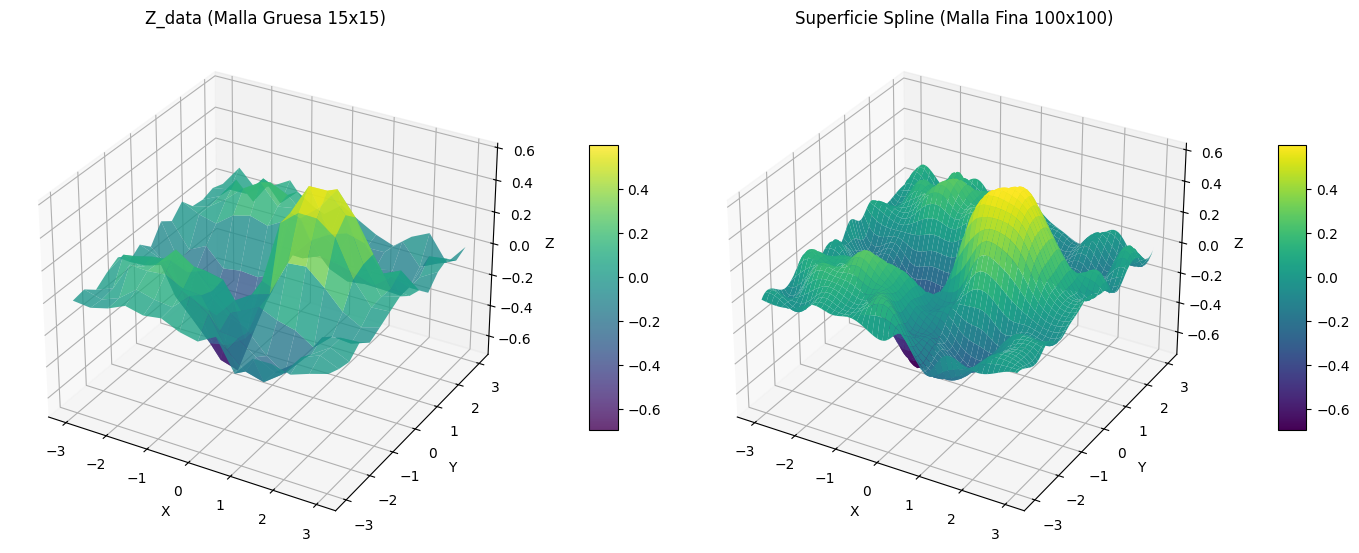

In [13]:
import matplotlib.pyplot as plt
from matplotlib import cm

# Determinar límites de color comunes para consistencia
vmin = np.min(Z_data)
vmax = np.max(Z_data)

fig = plt.figure(figsize=(14, 6))

# --- Panel Izquierdo: Datos Originales (Z_data) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='none', alpha=0.8)
ax1.set_title('Z_data (Malla Gruesa 15x15)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# --- Panel Derecho: Spline Interpolado (Z_spline) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X_fine, Y_fine, Z_spline, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='none')
ax2.set_title('Superficie Spline (Malla Fina 100x100)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

# Agregar barras de color
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, pad=0.1)

plt.tight_layout()
plt.show()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [14]:
# 1. Aplanar los datos para el ajuste (225 puntos)
x_flat = X_raw.flatten()
y_flat = Y_raw.flatten()
z_flat = Z_data.flatten()

# 2. Construir la matriz A (N x 3)
# Columna 1: Unos (c0), Columna 2: x (c1), Columna 3: y (c2)
A = np.column_stack((np.ones_like(x_flat), x_flat, y_flat))

# 3. Resolver por mínimos cuadrados
# np.linalg.lstsq retorna (coeficientes, residuos, rango, valores singulares)
coeffs, _, _, _ = np.linalg.lstsq(A, z_flat, rcond=None)
c0, c1, c2 = coeffs

# 4. Imprimir coeficientes
print(f"Coeficientes del plano ajustado:")
print(f"c0 (intercepto): {c0:.4f}")
print(f"c1 (pendiente x): {c1:.4f}")
print(f"c2 (pendiente y): {c2:.4f}")

Coeficientes del plano ajustado:
c0 (intercepto): -0.0047
c1 (pendiente x): 0.0071
c2 (pendiente y): -0.0006


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

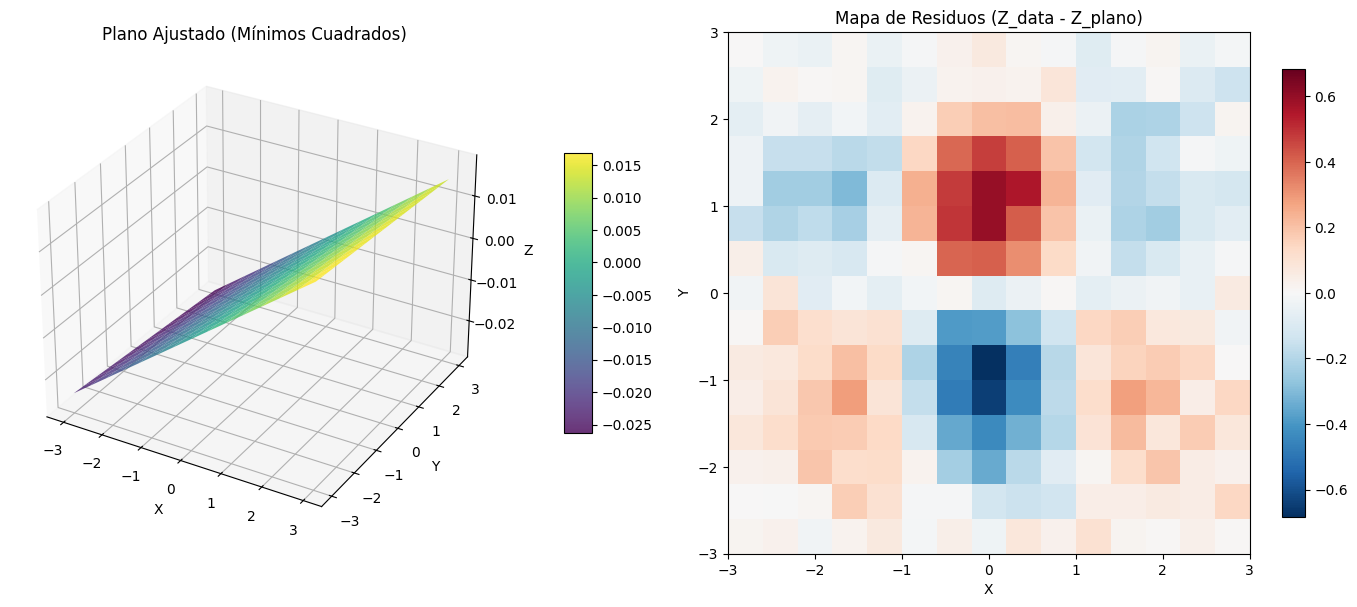

In [15]:
# 1. Evaluar el plano en la malla gruesa (15x15)
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# 2. Calcular mapa de residuos
R = Z_data - Z_plano

# 3. Crear la figura
fig = plt.figure(figsize=(14, 6))

# --- Panel Izquierdo: Plano Ajustado (3D) ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_plano, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_title('Plano Ajustado (Mínimos Cuadrados)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, pad=0.1)

# --- Panel Derecho: Mapa de Residuos (2D) ---
ax2 = fig.add_subplot(1, 2, 2)
# Usamos colormap divergente 'RdBu_r' centrado en cero
limit = np.max(np.abs(R))
im = ax2.imshow(R, extent=[-3, 3, -3, 3], origin='lower', cmap='RdBu_r', vmin=-limit, vmax=limit)
ax2.set_title('Mapa de Residuos (Z_data - Z_plano)')
ax2.set_xlabel('X'); ax2.set_ylabel('Y')
fig.colorbar(im, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.show()

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [ ]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
